# Action potential waveforms are state-dependent
### Finding 5 of 5

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

For over a century, neuroscience has treated the action potential as a binary, all-or-none event, every spike functionally identical to the next. This paper asks whether that abstraction throws away real information. It turns out the shape of a single spike, not just whether or when it fired, varies with the input driving the neuron, varies more from spike to spike within one neuron than expected, and tracks the surrounding network state.

This notebook walks through one of the paper's five findings. See the [repo README](README.md) for the full picture and the other four notebooks.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

AP1 = 'AP_empirical_paper_all_analyses'
sys.path.append(f'{AP1}/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets, aggregate_population, run_population_tests,
    run_fraction_sig_tests, run_r2_tests, plot_r2_summary_boxplot,
    plot_beta_significant_summary,
)
from ridge_regression_utils import FEAT_LABELS

RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
ALPHA     = 0.05
MIN_CELLS = 5

## AP waveform predicts peri-spike LFP state

**Finding:** the shape of a single intracellular spike carries information about the local field potential (LFP) happening around it, beyond what firing rate alone tells you.

Across 39 cells with usable LFP recordings, a ridge regression using only spike-shape features predicted LFP amplitude and variability in the 50 ms before and after each spike, significantly above zero at the population level. Where the relationship was significant, three features carried a consistent direction across cells: spikes with a bigger inflection amplitude, a faster decay rate, and a smaller ramp amplitude tend to occur during higher-amplitude surrounding LFP.

**Figure:** per-target cross-validated R² across cells (top); population-level beta weights for the targets where the relationship is significant, colored by direction (bottom) (Fig. 5).

Merged: 39 cells  |  14 targets (Pre+Post abs + HPF amp/std, no BL-corrected or Δ)
Fraction-sig binomial tests: 42 pairs  |  p<0.05: 40 (each target tested independently)
      target_label      predictor_set  n_sig  n_cells  frac_sig
       Pre LFP Amp      Waveform only     34       39  0.871795
       Pre LFP Amp       Log ISI only     18       39  0.461538
       Pre LFP Amp Waveform + Log ISI     35       39  0.897436
 Pre LFP Amp (HPF)      Waveform only     25       39  0.641026
 Pre LFP Amp (HPF)       Log ISI only     15       39  0.384615
 Pre LFP Amp (HPF) Waveform + Log ISI     28       39  0.717949
       Pre LFP Std      Waveform only     29       39  0.743590
       Pre LFP Std       Log ISI only     15       39  0.384615
       Pre LFP Std Waveform + Log ISI     32       39  0.820513
 Pre LFP Std (HPF)      Waveform only     19       39  0.487179
 Pre LFP Std (HPF)       Log ISI only     13       39  0.333333
 Pre LFP Std (HPF) Waveform + Log ISI     24       39  0.6153

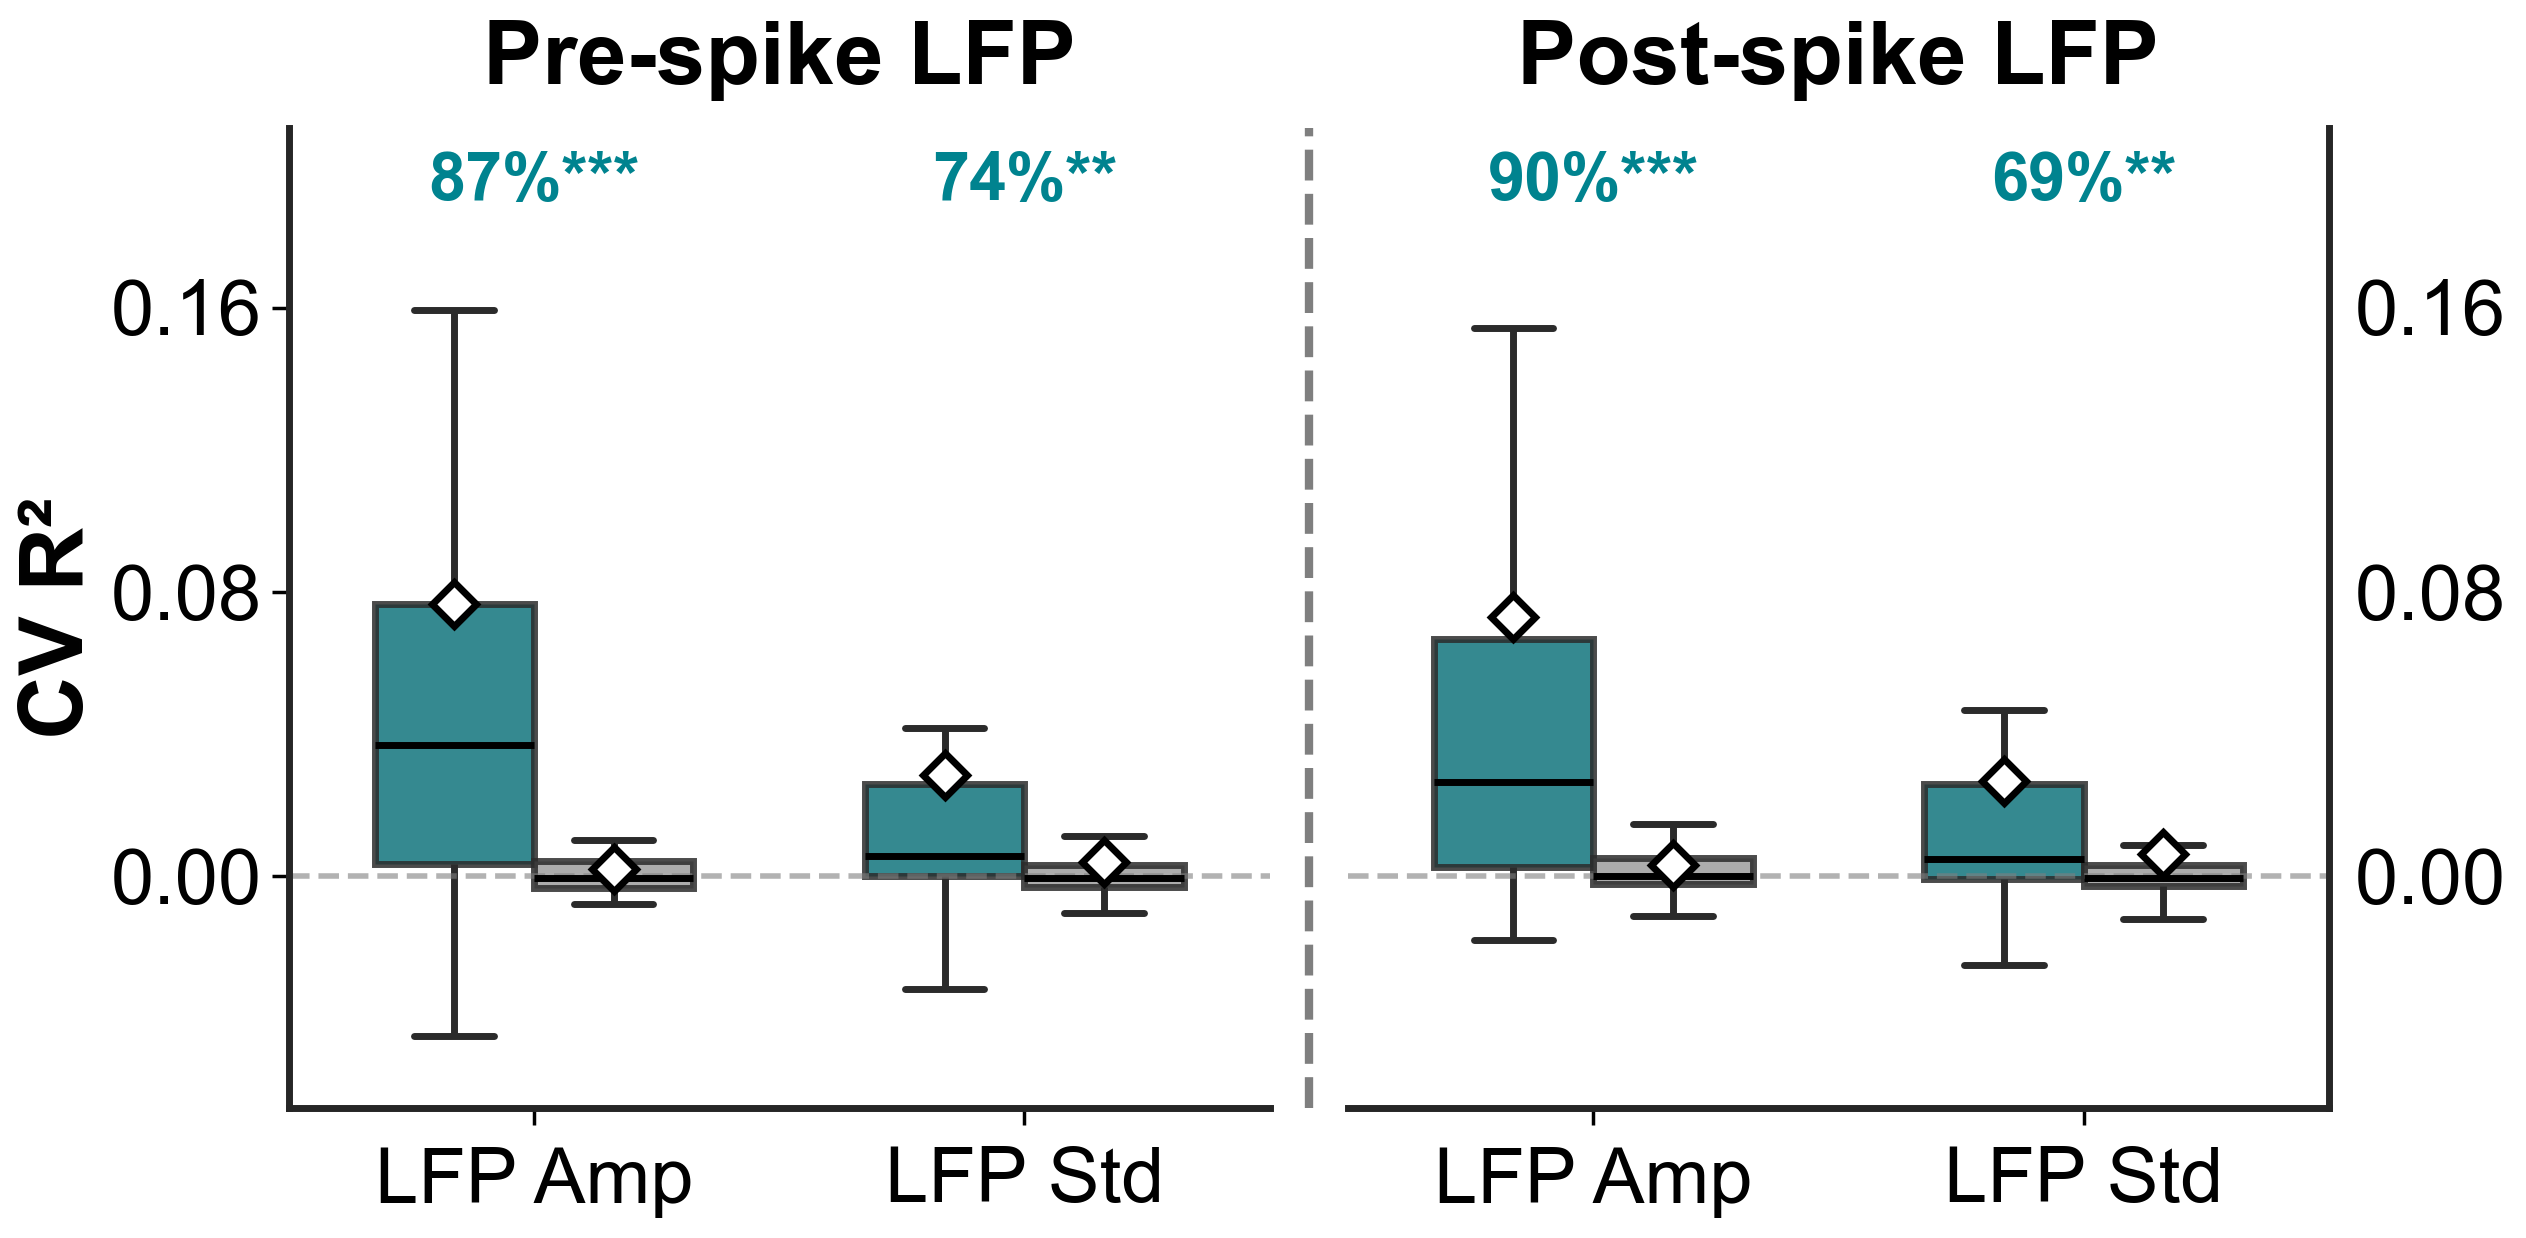

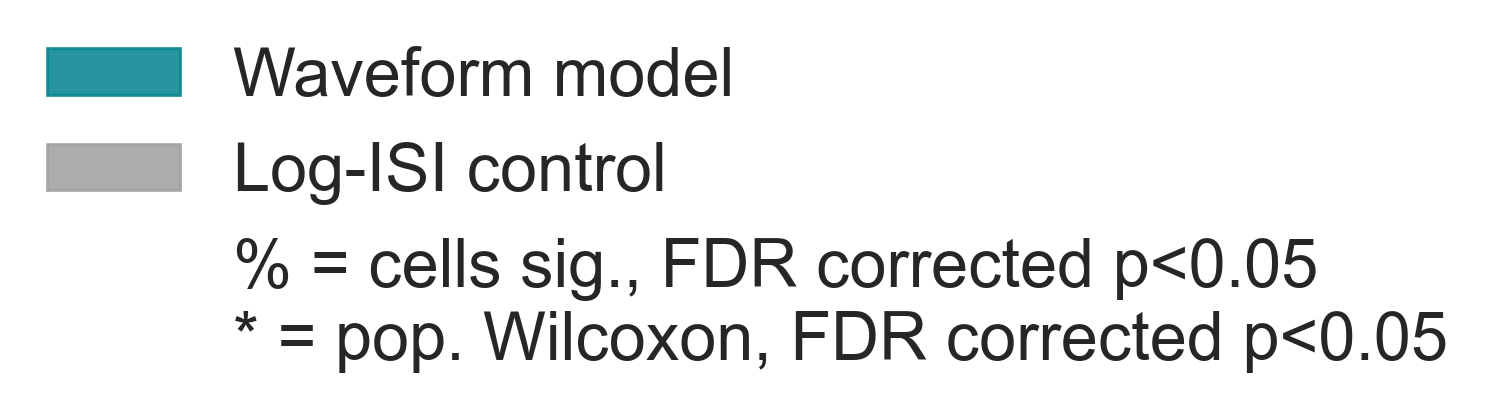

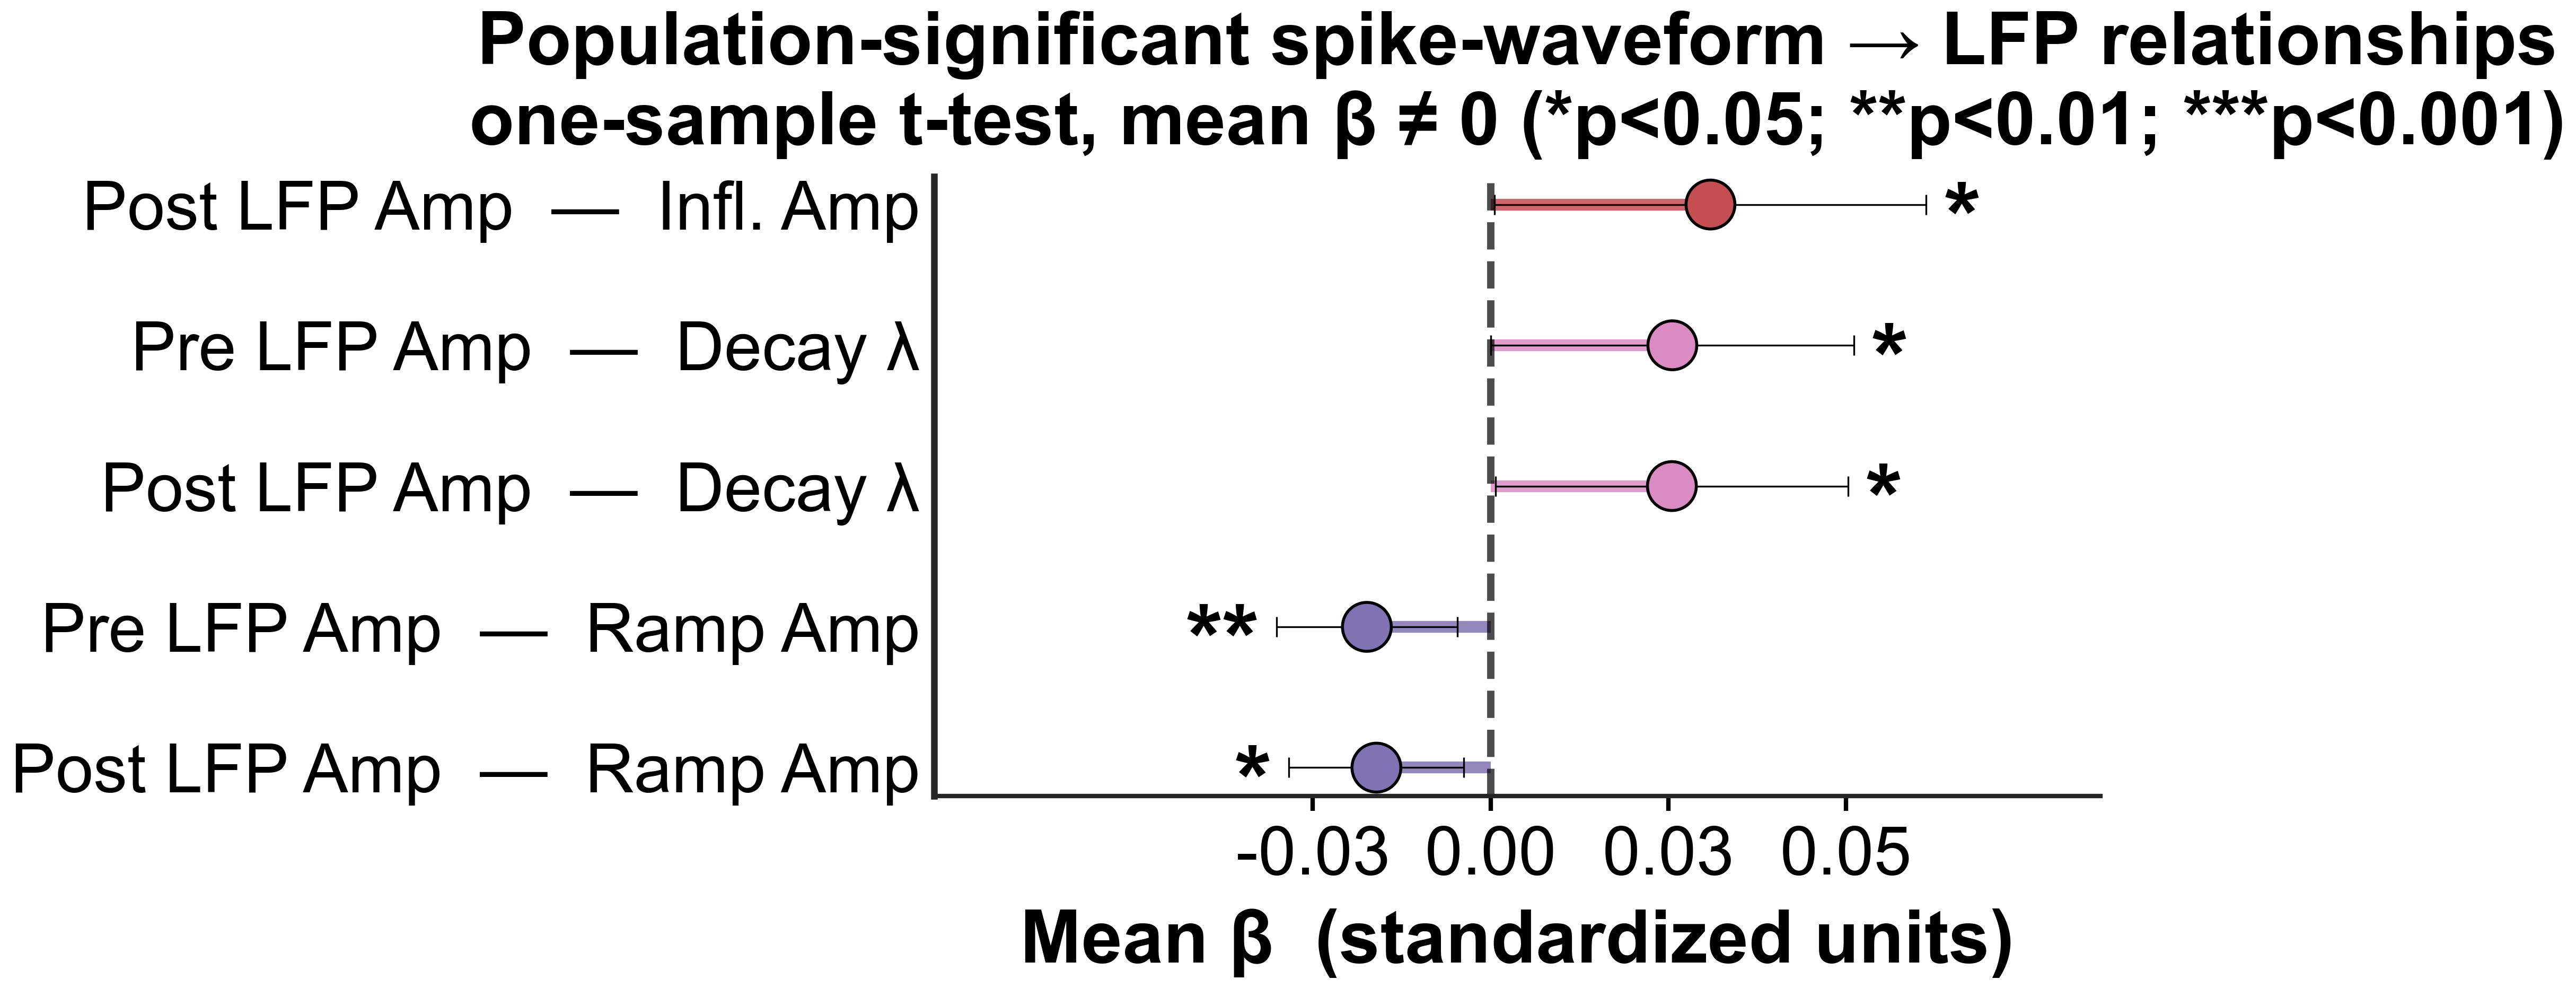

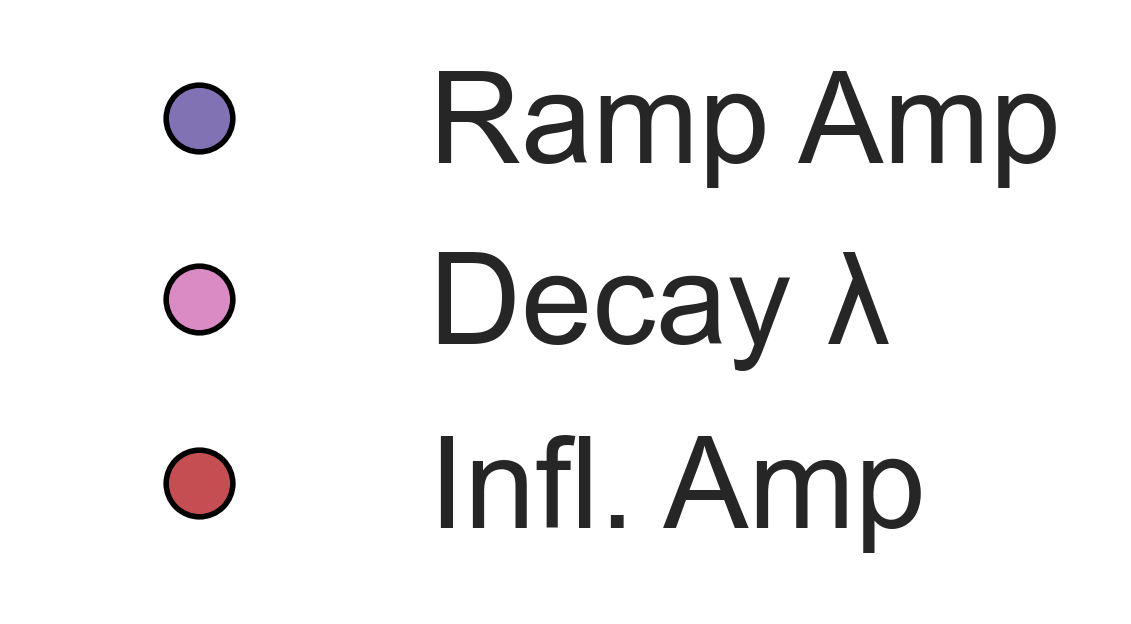

(<Figure size 2200x800 with 1 Axes>,
 <Axes: title={'center': 'Population-significant spike-waveform → LFP relationships\none-sample t-test, mean β ≠ 0 (*p<0.05; **p<0.01; ***p<0.001)'}, xlabel='Mean β  (standardized units)'>)

In [2]:
# Same pipeline as pop_ridge_regression.ipynb, cells 6, 9, 14, 20, 27.
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

df_frac = run_fraction_sig_tests(
    sig_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
print(f'R2-significant targets (Waveform only): {sig_r2_targets}')

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

plot_r2_summary_boxplot(r2_pop, sig_pop, df_r2, target_names, target_labels,
                        predictor_set='Waveform only')
plot_beta_significant_summary(df_tests, target_names, target_labels)